# 01 · 사출성형기 데이터 탐색
대회 주제 선정에 앞서 데이터의 규모, 품질, 라벨 구분 가능성, 데이터 그룹 간 차이를 살펴봅니다.

**대상:** `moldset_{labeled,unlabeled}_{cn7,rg3}.csv` 4개 파일. 원본은 수정하지 않습니다.

**해석 원칙**
- `PassOrFail`의 0/1 의미는 제공된 파일만으로 확정할 수 없어 숫자 그대로 표시합니다.
- 값에 음수가 포함되어 전처리된 데이터일 가능성이 있습니다. 원래 물리 단위와 정규화 방식을 확인하기 전에는 온도·압력의 실측값으로 해석하지 않습니다.
- 첫 번째 이름 없는 열은 원본 행 식별자로 보관하고 공정 변수에서 제외합니다. 행 순서를 시간으로 가정하지 않습니다.
- 전체 데이터 탐색 결과는 모델 성능이 아닙니다. 변수 선택과 전처리는 추후 학습 데이터 안에서 다시 수행해야 합니다.

**실행:** 프로젝트 또는 `notebooks` 폴더에서 Python 커널로 위에서부터 실행합니다.
필요한 패키지는 `python -m pip install -r notebooks/requirements.txt`로 설치할 수 있습니다(프로젝트 루트 기준).


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

SEED = 42
pd.set_option('display.max_columns', 35)
fonts = {f.name for f in font_manager.fontManager.ttflist}
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    if font in fonts:
        plt.rcParams['font.family'] = font
        break
plt.rcParams.update({'axes.unicode_minus': False, 'figure.dpi': 110,
                     'axes.spines.top': False, 'axes.spines.right': False})
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('data 폴더가 있는 프로젝트 안에서 실행하세요.')
files = sorted((ROOT / 'data').glob('1*/**/moldset_*.csv'))
assert len(files) == 4, f'예상한 CSV는 4개입니다. 발견: {len(files)}'
frames = {}
for path in files:
    frame = pd.read_csv(path)
    if str(frame.columns[0]).startswith('Unnamed:'):
        frame = frame.rename(columns={frame.columns[0]: 'source_row_id'})
    frames[path.stem.removeprefix('moldset_')] = frame
TARGET = 'PassOrFail'
features = [c for c in next(iter(frames.values())).columns if c not in [TARGET, 'source_row_id']]
for name, frame in frames.items():
    assert set(features) == set(frame.columns) - {TARGET, 'source_row_id'}, name
    assert all(pd.api.types.is_numeric_dtype(frame[c]) for c in features), name
print('데이터 경로:', files[0].parent)
display(next(iter(frames.values())).head())


,source_row_id,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,1.679123,1.491397,-0.478017,0.361047,0.97858,-0.711164,1.532018,0.0,-1.152398,-0.795730,-0.132022,0.63521,1.256518,-0.916676,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,1,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,0.049553,-0.132022,0.63521,1.573231,-0.740752,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,2,0,2.080358,1.894372,-0.527100,1.886261,0.97858,-0.711164,1.471608,0.0,-1.347095,0.049553,-0.132022,0.63521,1.573231,-0.740752,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,3,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,1.740153,-0.132022,0.63521,1.256518,-0.740752,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,4,0,1.679123,1.894372,-0.527100,1.377857,0.97858,1.202502,1.471608,0.0,-1.347095,1.740153,-0.132022,0.63521,1.256518,-0.740752,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339


데이터 경로: C:\Users\User\Desktop\Projects\manufacturing-ai-competition\data\1. 사출성형기 AI 데이터셋\1. 사출성형기 AI 데이터셋


## 1. 파일 규모와 데이터 품질
중복은 행 ID를 제외한 공정 변수 조합을 기준으로 계산합니다. 반복 공정에서 같은 값이 나올 수 있으므로 자동 삭제하지 않습니다.


,rows,features,labeled_rows,missing_cells,infinite_cells,duplicate_features,constant_features
dataset,,,,,,,
labeled_cn7,1211,24,1211,0,0,605,1
labeled_rg3,1182,24,1182,0,0,591,1
unlabeled_cn7,35239,24,0,0,0,6468,0
unlabeled_rg3,35941,24,0,0,0,6234,0


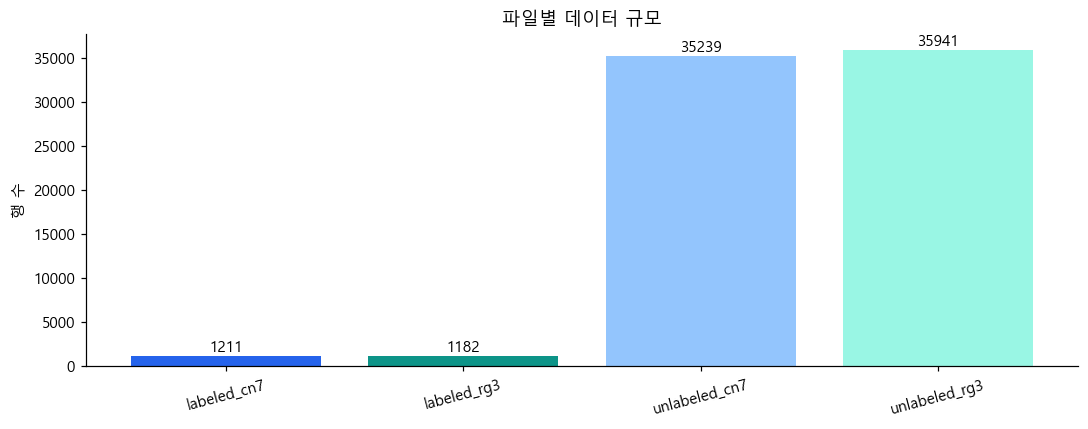

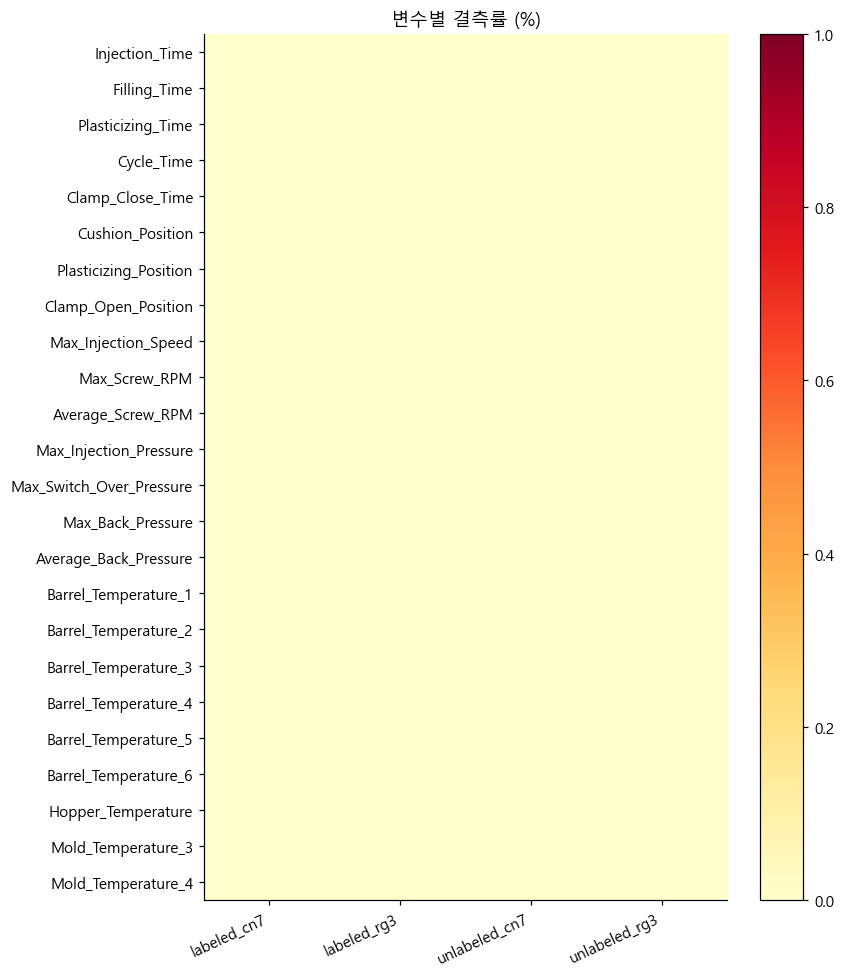

,labeled_cn7,labeled_rg3,unlabeled_cn7,unlabeled_rg3
고유값 수,,,,
Injection_Time,15,3,115,91
Filling_Time,14,2,124,97
Plasticizing_Time,34,27,307,470
Cycle_Time,13,10,251,371
Clamp_Close_Time,3,3,69,88
Cushion_Position,5,7,85,68
Plasticizing_Position,13,8,169,207
Clamp_Open_Position,1,1,47,53
Max_Injection_Speed,20,7,242,179


In [2]:
summary = []
for name, df in frames.items():
    x = df[features]
    summary.append({'dataset': name, 'rows': len(df), 'features': len(features),
                    'labeled_rows': int(df[TARGET].notna().sum()) if TARGET in df else 0,
                    'missing_cells': int(x.isna().sum().sum()),
                    'infinite_cells': int(np.isinf(x.to_numpy(dtype=float)).sum()),
                    'duplicate_features': int(x.duplicated().sum()),
                    'constant_features': int(x.nunique(dropna=True).le(1).sum())})
summary = pd.DataFrame(summary).set_index('dataset')
display(summary)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(summary.index, summary['rows'], color=['#2563eb', '#0d9488', '#93c5fd', '#99f6e4'])
ax.bar_label(bars, fmt='%.0f'); ax.set(ylabel='행 수', title='파일별 데이터 규모')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

missing = pd.DataFrame({k: v[features].isna().mean() * 100 for k, v in frames.items()})
fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(missing, aspect='auto', cmap='YlOrRd', vmin=0, vmax=max(1, missing.max().max()))
ax.set_xticks(range(len(missing.columns)), missing.columns, rotation=25, ha='right')
ax.set_yticks(range(len(features)), features); ax.set_title('변수별 결측률 (%)')
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
display(pd.DataFrame({k: v[features].nunique() for k, v in frames.items()}).rename_axis('고유값 수'))
# 무한값은 분석용 복사본에서만 결측값으로 처리합니다.
clean = {k: v.replace([np.inf, -np.inf], np.nan) for k, v in frames.items()}


## 2. 라벨 분포
그룹별 라벨 수와 비율을 확인합니다. 소수 라벨이 적다면 정확도 하나로 모델을 평가하기 어렵습니다.


PassOrFail,0,1
group,,
CN7,1194,17
RG3,1157,25


PassOrFail,0,1
라벨 비율 (%),,
CN7,98.60,1.40
RG3,97.88,2.12


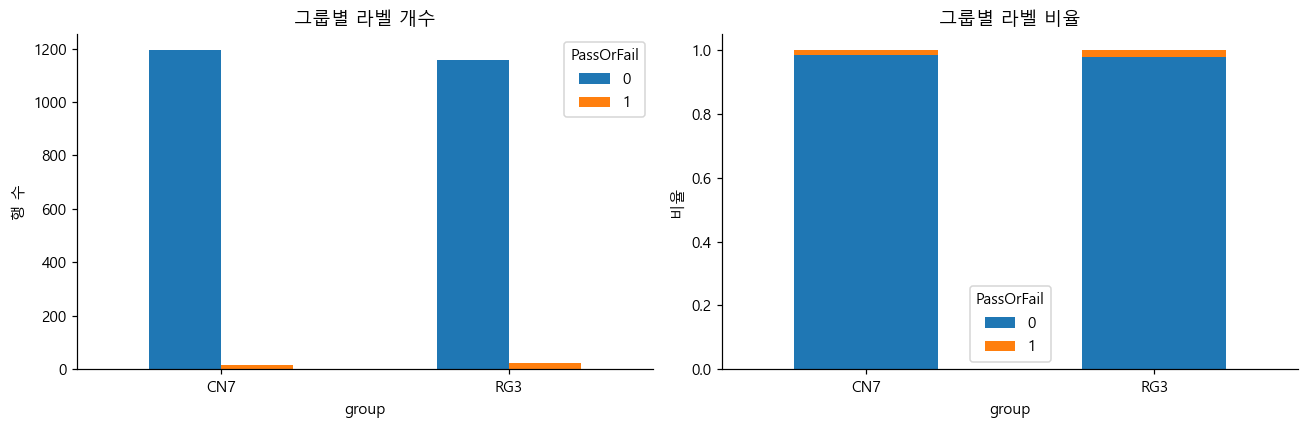

In [3]:
labeled = pd.concat([df.assign(group=name.rsplit('_', 1)[1].upper())
                     for name, df in clean.items() if TARGET in df], ignore_index=True)
label_counts = pd.crosstab(labeled['group'], labeled[TARGET])
display(label_counts)
display((label_counts.div(label_counts.sum(axis=1), axis=0) * 100).round(2).rename_axis('라벨 비율 (%)'))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts.plot.bar(ax=axes[0], rot=0, title='그룹별 라벨 개수')
label_counts.div(label_counts.sum(axis=1), axis=0).plot.bar(stacked=True, ax=axes[1], rot=0, title='그룹별 라벨 비율')
axes[0].set_ylabel('행 수'); axes[1].set_ylabel('비율')
plt.tight_layout(); plt.show()


## 3. 전체 공정 변수의 분포
각 히스토그램은 파일별 확률 밀도입니다. 표본 수 차이를 보정하여 모양을 비교합니다. 상수 변수도 그대로 보여 줍니다.


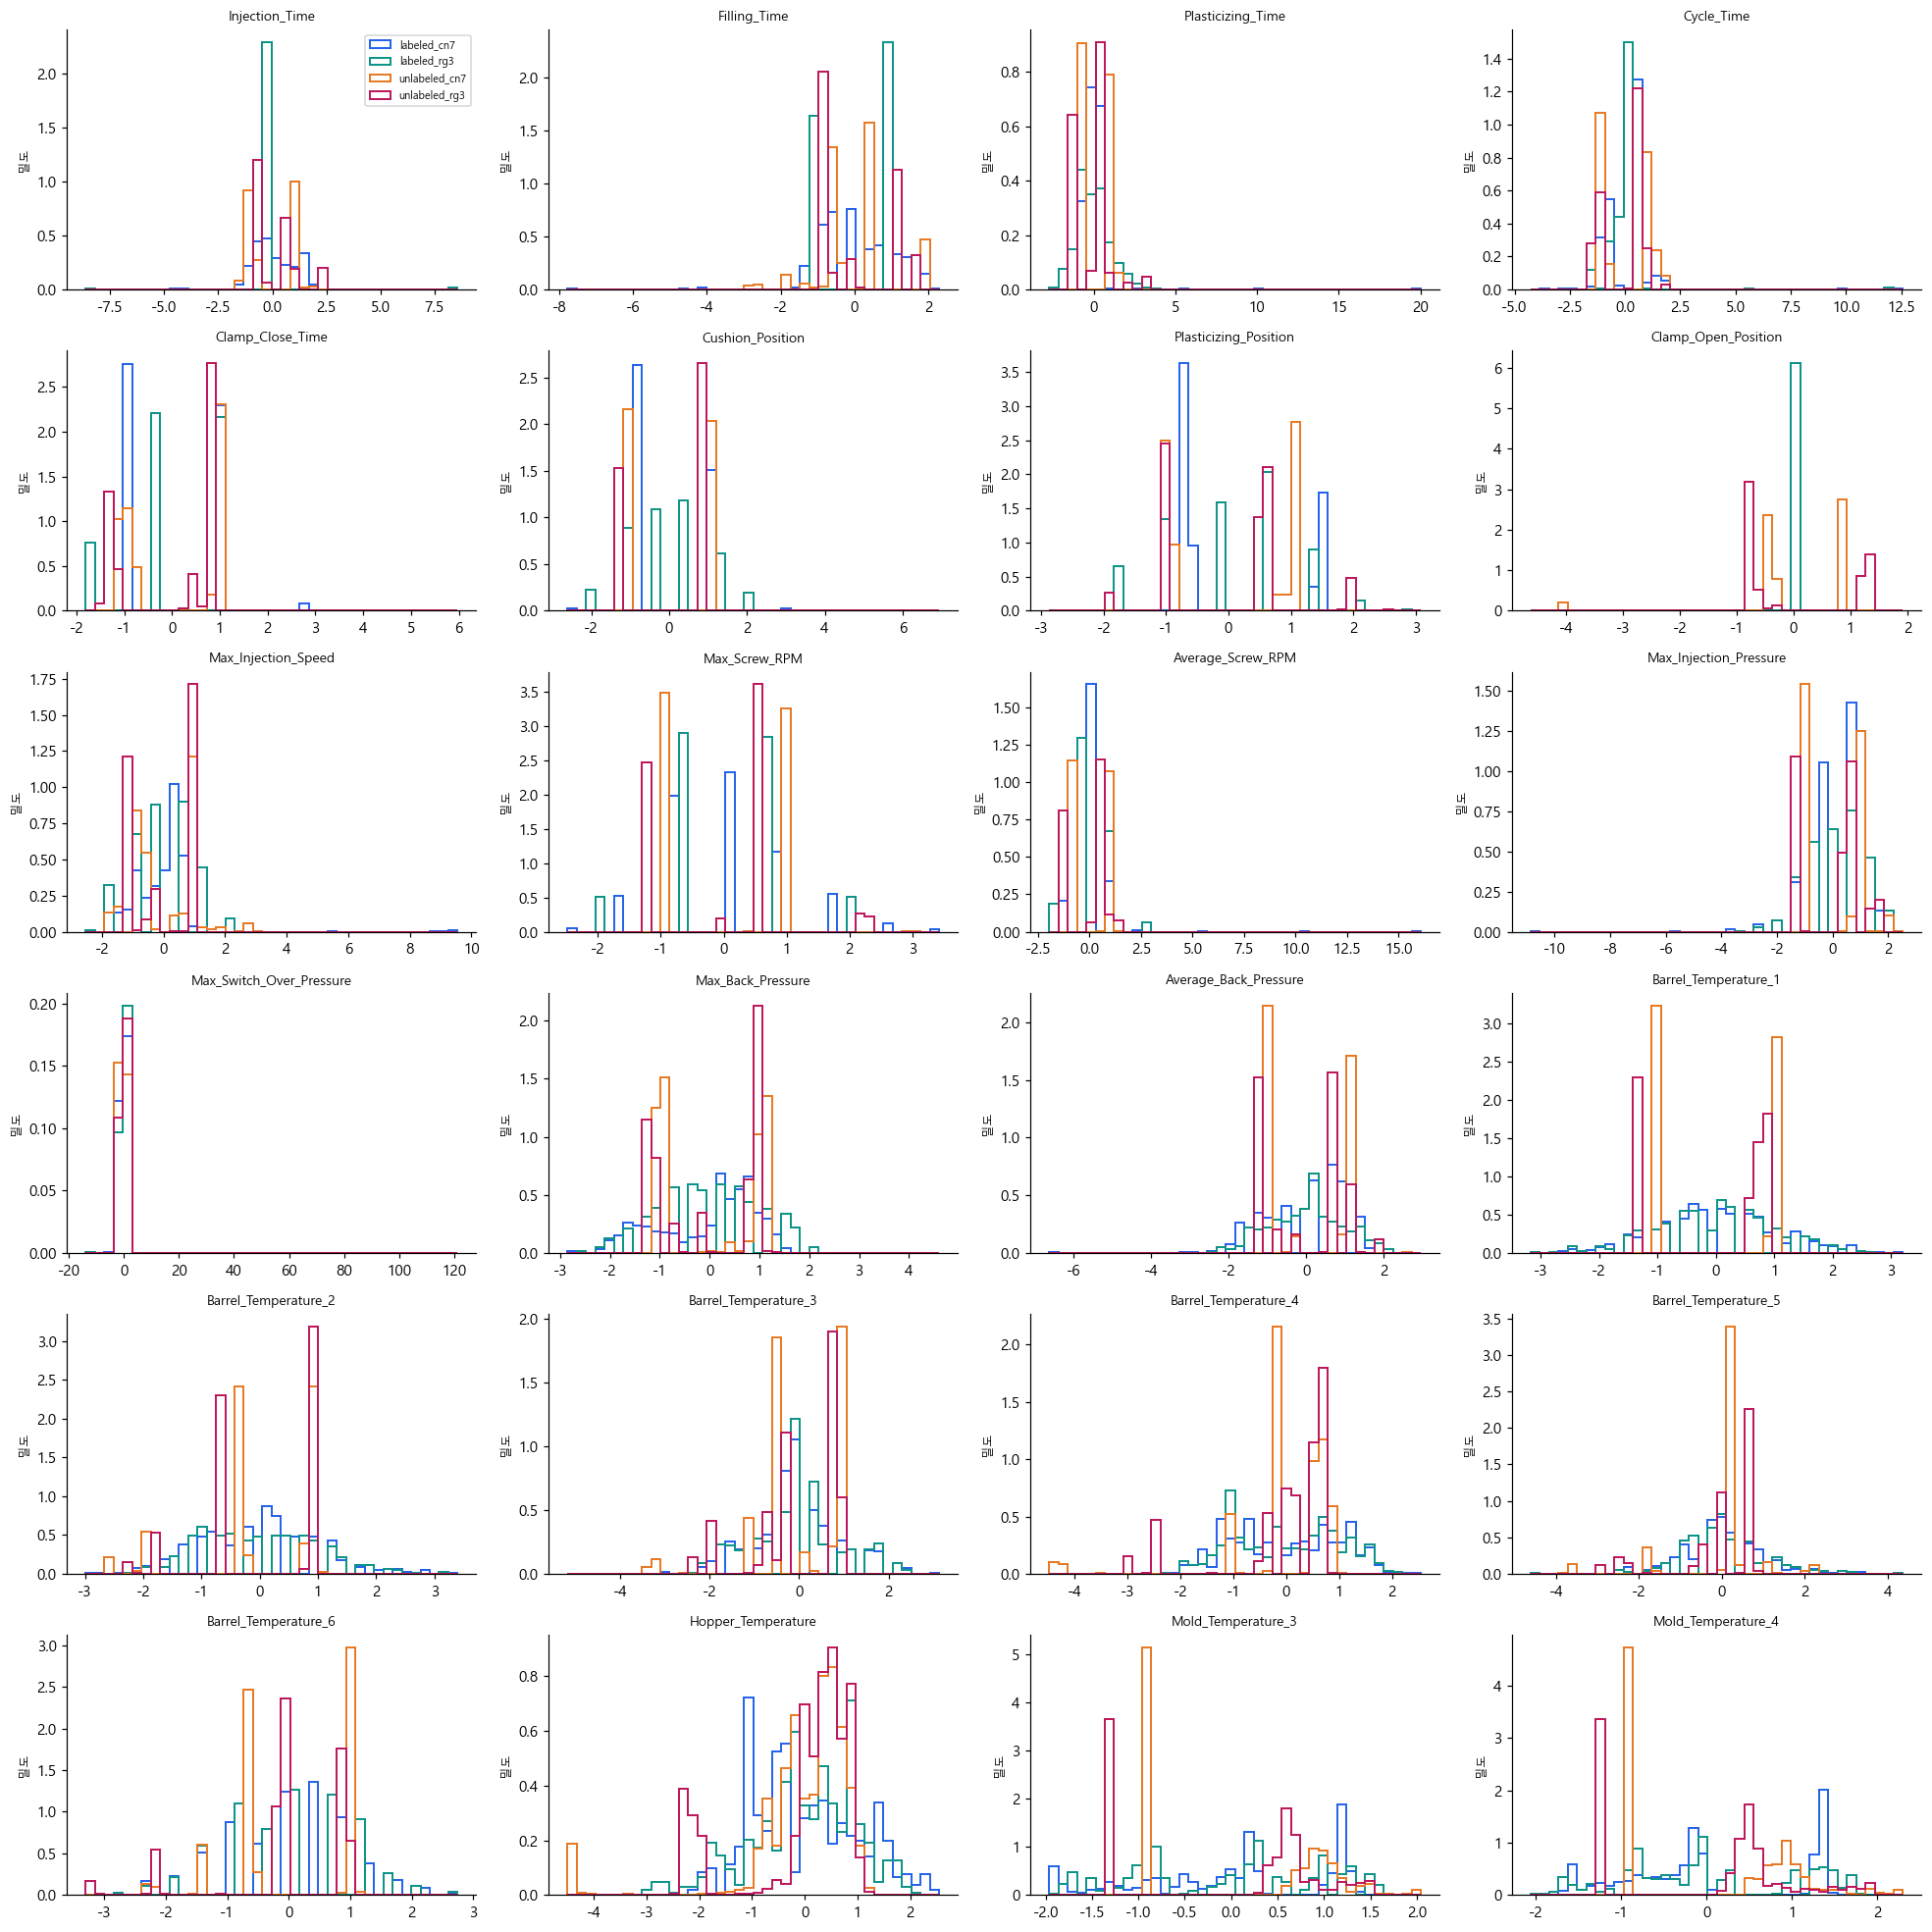

,count,mean,std,min,25%,50%,75%,max
Injection_Time,2393.0,-3.824401e-14,1.000209,-8.627730,-0.327014,-0.029099,-0.029099,8.569634
Filling_Time,2393.0,-2.826731e-15,1.000209,-7.776799,-0.926390,-0.120461,0.838552,2.297327
Plasticizing_Time,2393.0,-5.415921e-15,1.000209,-2.736231,-0.491498,-0.042538,0.307302,20.038456
Cycle_Time,2393.0,5.281414e-14,1.000209,-3.706092,-0.655762,0.249511,0.361047,12.562466
Clamp_Close_Time,2393.0,1.656844e-14,1.000209,-1.806725,-0.902466,-0.386790,0.978580,2.859537
Cushion_Position,2393.0,3.720892e-12,1.000209,-2.613163,-0.711164,-0.317055,1.202502,6.943503
Plasticizing_Position,2393.0,7.126212e-14,1.000209,-2.876962,-0.702654,-0.192928,0.588367,2.932550
Clamp_Open_Position,2393.0,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Max_Injection_Speed,2393.0,-1.199579e-14,1.000209,-2.522291,-0.763018,0.015756,0.599832,9.555703
Max_Screw_RPM,2393.0,-9.335338e-15,1.000209,-2.486330,-0.665752,0.049553,0.677109,3.430752


In [4]:
fig, axes = plt.subplots(int(np.ceil(len(features) / 4)), 4, figsize=(18, 18))
colors = ['#2563eb', '#0d9488', '#e87924', '#be185d']
for ax, col in zip(axes.flat, features):
    vals = [df[col].dropna().to_numpy() for df in clean.values()]
    pooled = np.concatenate(vals)
    if not len(pooled):
        ax.set_title(col + ' (유효값 없음)'); continue
    edges = np.histogram_bin_edges(pooled, bins=40)
    for (name, df), color in zip(clean.items(), colors):
        v = df[col].dropna()
        if len(v):
            ax.hist(v, bins=edges, density=True, histtype='step', linewidth=1.3, label=name, color=color)
    ax.set_title(col, fontsize=9); ax.set_ylabel('밀도', fontsize=8)
for ax in list(axes.flat)[len(features):]: ax.set_visible(False)
axes.flat[0].legend(fontsize=7)
plt.tight_layout(); plt.show()
display(labeled[features].describe().T)


## 4. 변수 간 상관관계
CN7와 RG3를 각각 분석합니다. 상수 변수의 상관계수는 정의되지 않아 빈칸으로 표시됩니다. 상관관계는 인과관계가 아닙니다.


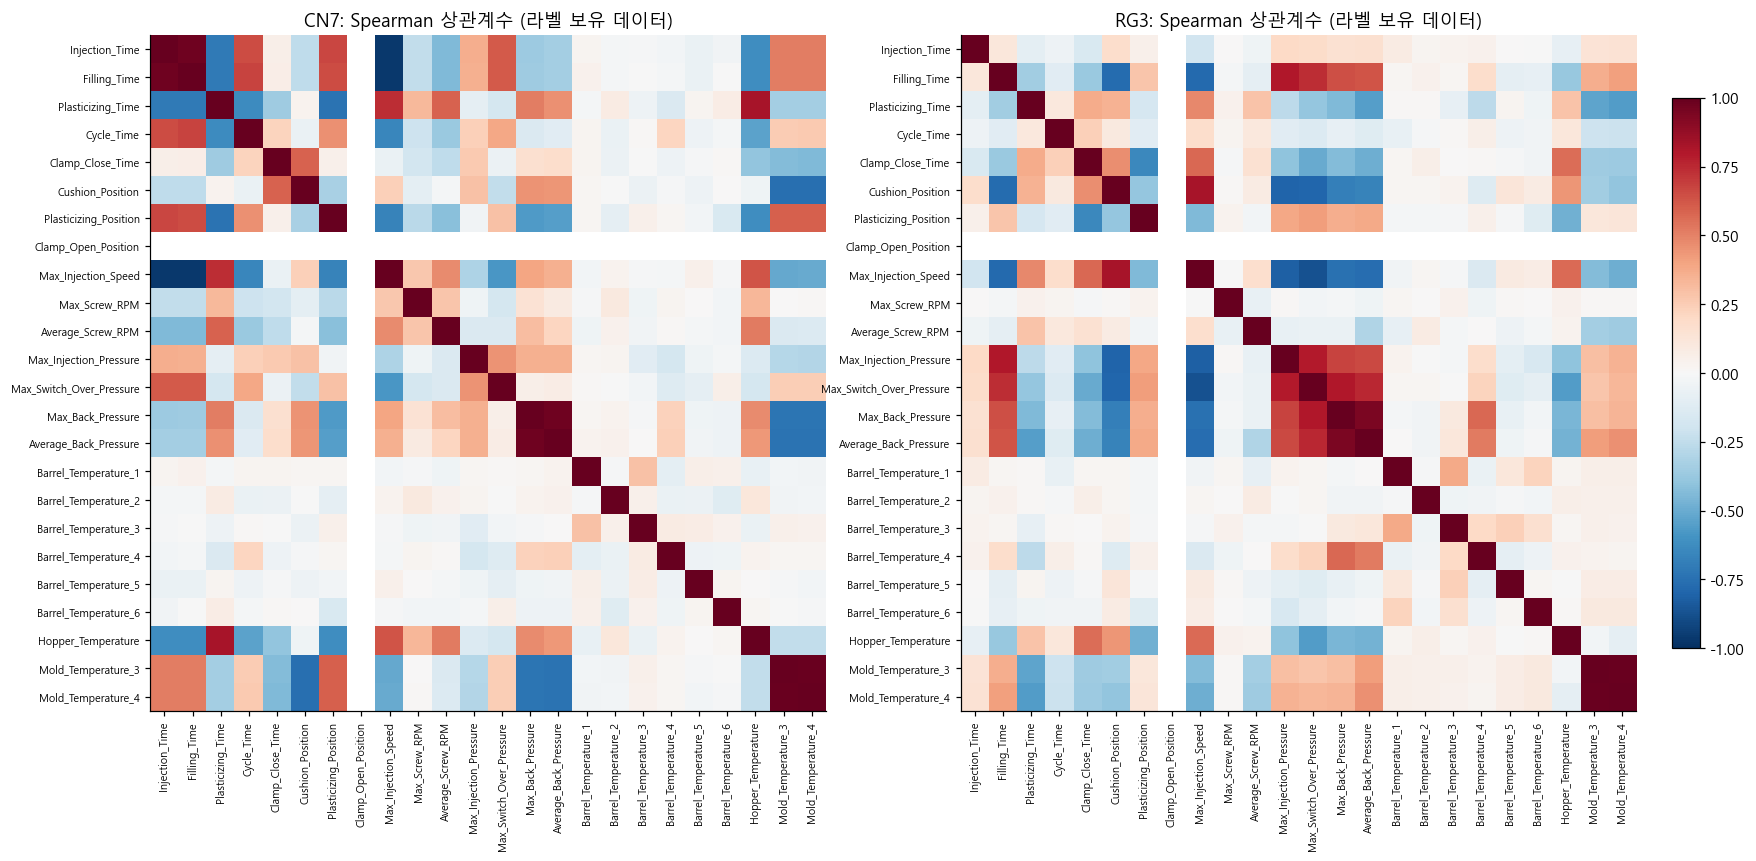

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(21, 10))
for ax, (group, df) in zip(axes, labeled.groupby('group')):
    corr = df[features].corr(method='spearman')
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(features)), features, rotation=90, fontsize=7)
    ax.set_yticks(range(len(features)), features, fontsize=7)
    ax.set_title(f'{group}: Spearman 상관계수 (라벨 보유 데이터)')
fig.colorbar(im, ax=axes.tolist(), shrink=.65, pad=.02)
plt.show()


## 5. 라벨별 차이가 큰 변수
그룹 내부에서 라벨 0·1의 평균 차이를 두 라벨 분산의 평균 제곱근으로 나누어 비교합니다. 탐색용 효과 크기이며 검증 성능이나 중요도는 아닙니다. 분산이 0인 변수는 제외합니다.


,CN7,RG3
Plasticizing_Position,2.162762,-0.107328
Mold_Temperature_4,1.970737,-0.084371
Mold_Temperature_3,1.746339,-0.091884
Max_Back_Pressure,-1.691928,0.075932
Average_Back_Pressure,-1.481356,0.061610
Clamp_Close_Time,1.465428,0.192717
Cushion_Position,-1.220081,-0.064171
Max_Switch_Over_Pressure,0.929425,0.123653
Hopper_Temperature,-0.853325,-0.141864
Max_Injection_Pressure,-0.823745,0.022110


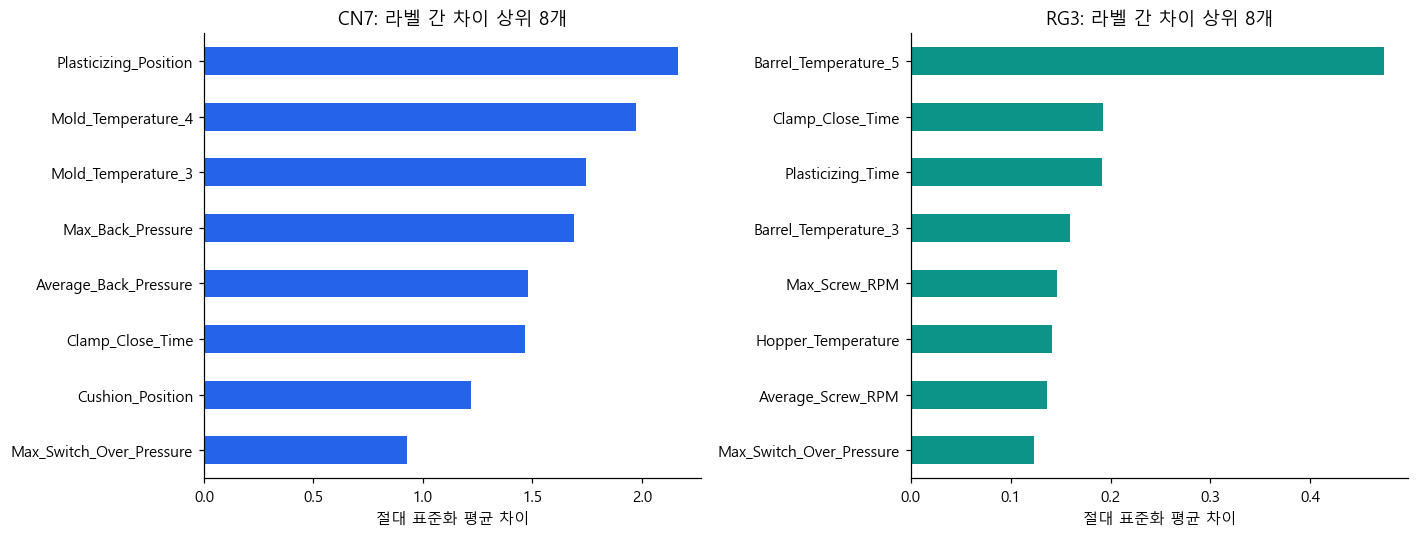

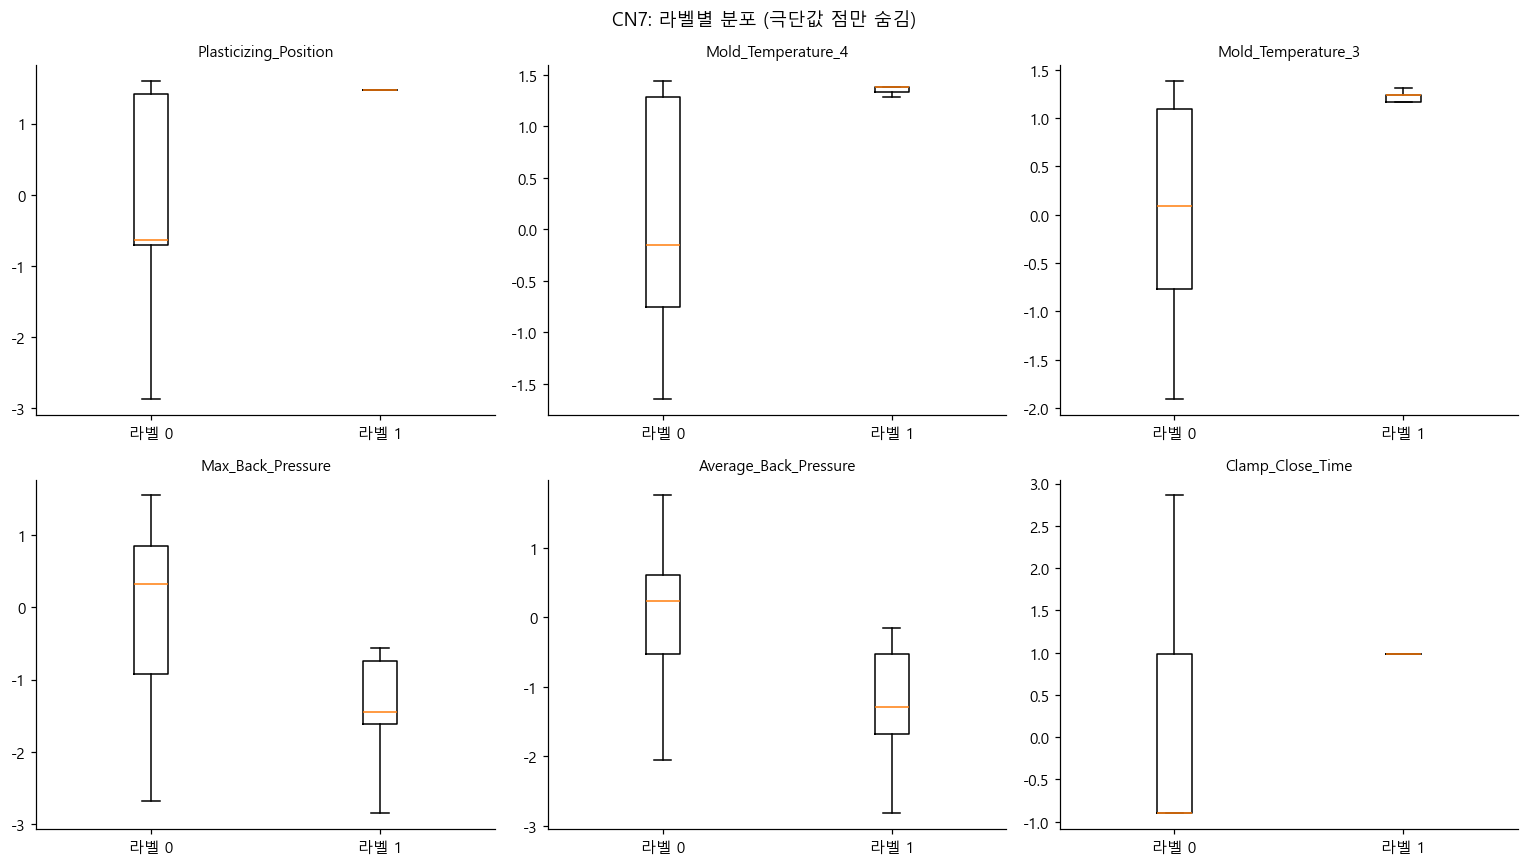

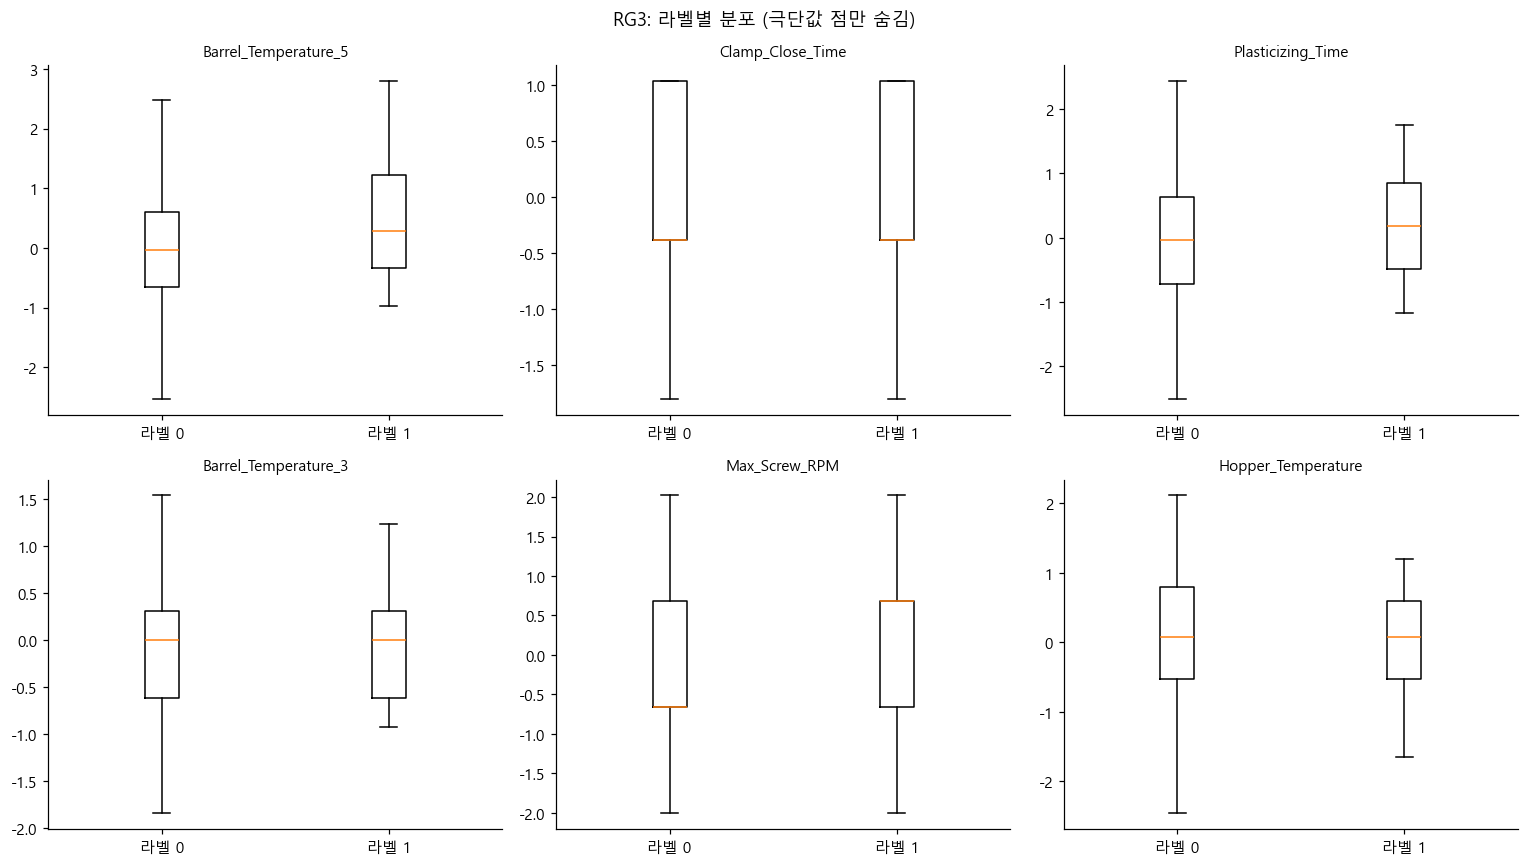

In [6]:
effects = {}
for group, df in labeled.groupby('group'):
    if set(df[TARGET].dropna().unique()) != {0, 1}:
        raise ValueError(f'{group}: 라벨 값 확인이 필요합니다.')
    a, b = df.loc[df[TARGET].eq(0), features], df.loc[df[TARGET].eq(1), features]
    denominator = np.sqrt((a.var() + b.var()) / 2).replace(0, np.nan)
    effects[group] = (b.mean() - a.mean()) / denominator
effect_table = pd.DataFrame(effects)
display(effect_table.reindex(effect_table.abs().max(axis=1).sort_values(ascending=False).index))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, group in zip(axes, effects):
    top = effects[group].abs().dropna().nlargest(8).sort_values()
    top.plot.barh(ax=ax, color='#2563eb' if group == 'CN7' else '#0d9488')
    ax.set_title(f'{group}: 라벨 간 차이 상위 8개'); ax.set_xlabel('절대 표준화 평균 차이')
plt.tight_layout(); plt.show()

for group, df in labeled.groupby('group'):
    top = effects[group].abs().dropna().nlargest(6).index
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, col in zip(axes.flat, top):
        values = [df.loc[df[TARGET].eq(label), col].dropna() for label in [0, 1]]
        ax.boxplot(values, tick_labels=['라벨 0', '라벨 1'], showfliers=False)
        ax.set_title(col, fontsize=10)
    for ax in list(axes.flat)[len(top):]: ax.set_visible(False)
    fig.suptitle(f'{group}: 라벨별 분포 (극단값 점만 숨김)')
    plt.tight_layout(); plt.show()


## 6. 라벨 보유·미보유 데이터의 분포 차이
그룹별로 평균 차이를 라벨 보유 데이터의 표준편차로 나눕니다. 큰 차이는 예측 대상 데이터에 모델을 적용할 때 확인할 사항입니다. 라벨 미보유 데이터를 학습 평가용 정답 데이터로 사용할 수는 없습니다.


,CN7,RG3
Cushion_Position,-4.628749e-12,-2.787858e-12
Plasticizing_Position,3.621745e-14,-1.811741e-13
Max_Injection_Pressure,-1.077561e-13,7.266742e-14
Average_Screw_RPM,-4.192055e-14,8.439286e-14
Barrel_Temperature_5,-3.823198e-15,7.942053e-14
Cycle_Time,-4.989948e-14,-5.487673e-14
Clamp_Close_Time,1.566422e-14,-5.026141e-14
Barrel_Temperature_4,-1.127937e-14,-4.771519e-14
Injection_Time,2.966270e-14,4.727228e-14
Barrel_Temperature_1,1.829169e-14,4.450302e-14


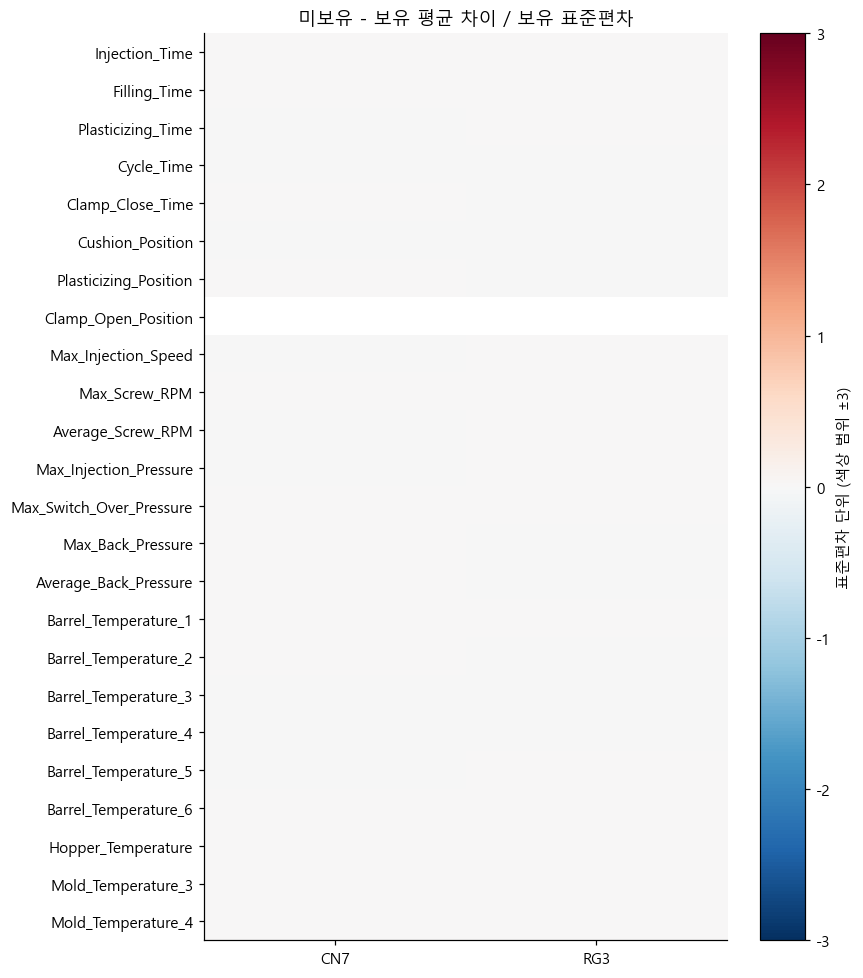

,group,shared_feature_patterns
0,CN7,0
1,RG3,0


In [7]:
shift = {}
for group in ['cn7', 'rg3']:
    train, other = clean[f'labeled_{group}'][features], clean[f'unlabeled_{group}'][features]
    shift[group.upper()] = (other.mean() - train.mean()) / train.std().replace(0, np.nan)
shift = pd.DataFrame(shift)
display(shift.reindex(shift.abs().max(axis=1).sort_values(ascending=False).index).head(10))
fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(shift, aspect='auto', cmap='RdBu_r', vmin=-3, vmax=3)
ax.set_xticks([0, 1], shift.columns); ax.set_yticks(range(len(features)), features)
ax.set_title('미보유 - 보유 평균 차이 / 보유 표준편차')
fig.colorbar(im, ax=ax, label='표준편차 단위 (색상 범위 ±3)')
plt.tight_layout(); plt.show()

overlaps = []
for group in ['cn7', 'rg3']:
    a, b = frames[f'labeled_{group}'], frames[f'unlabeled_{group}']
    # 해시 충돌에 의존하지 않고 실제 변수 조합으로 중복을 확인합니다.
    common = a[features].drop_duplicates().merge(b[features].drop_duplicates(), on=features, how='inner')
    overlaps.append({'group': group.upper(), 'shared_feature_patterns': len(common)})
display(pd.DataFrame(overlaps))


## 7. 주제 선정용 요약
아래 수치는 파일에서 자동 계산합니다. 최종 주제 선정은 다른 네 주제도 같은 기준으로 탐색한 뒤 진행합니다.


In [8]:
print(f'전체 {summary.rows.sum():,}행 / 공정 변수 {len(features)}개')
print(f'라벨 보유 {len(labeled):,}행 / 라벨 미보유 {summary.rows.sum() - len(labeled):,}행')
for group, counts in label_counts.iterrows():
    print(f'{group}: 라벨별 {counts.to_dict()}, 최소 라벨 비율 {counts.min()/counts.sum():.2%}')
for name, df in frames.items():
    constants = [c for c in features if df[c].nunique(dropna=True) <= 1]
    print(f'{name}: 상수/전부 결측 변수 {constants}')


전체 73,573행 / 공정 변수 24개
라벨 보유 2,393행 / 라벨 미보유 71,180행
CN7: 라벨별 {0: 1194, 1: 17}, 최소 라벨 비율 1.40%
RG3: 라벨별 {0: 1157, 1: 25}, 최소 라벨 비율 2.12%
labeled_cn7: 상수/전부 결측 변수 ['Clamp_Open_Position']
labeled_rg3: 상수/전부 결측 변수 ['Clamp_Open_Position']
unlabeled_cn7: 상수/전부 결측 변수 []
unlabeled_rg3: 상수/전부 결측 변수 []


### 주제 후보와 다음 확인 사항
- **현재 파일의 핵심 관찰:** 전체 73,573행 중 라벨 보유 데이터는 2,393행입니다. 라벨 1은 CN7 17건, RG3 25건으로 총 42건뿐입니다. 라벨 1의 의미를 확인하고 소수 클래스 검증 표본을 충분히 확보하는 것이 주제 수행의 주요 과제입니다.
- **중복 확인:** 행 ID를 제외한 공정 변수 기준 중복 행은 라벨 보유 CN7 605행, RG3 591행입니다(각 조합의 첫 행 제외). 단순 무작위 분할은 같은 변수 조합을 학습·검증에 동시에 포함할 수 있어 성능을 과대평가할 위험이 있습니다.
- **라벨 기반 품질 분류:** 라벨 정의를 확인한 뒤 CN7/RG3별 기준 모델과 통합 모델을 비교합니다. 불균형이 있으면 PR-AUC, 소수 클래스 재현율, 혼동행렬을 함께 평가합니다.
- **라벨 미보유 데이터 활용:** 라벨 보유 데이터와 분포가 비슷한지 확인한 뒤 준지도학습의 실효성을 검토합니다. 미보유 데이터의 정답이 없어 그 자체로 성능을 검증할 수는 없습니다.
- **공정 조건 분석:** 라벨별 분포 차이가 큰 변수를 공정 관점에서 해석합니다. 원래 단위와 전처리 방식이 없으면 물리적 조건 개선까지 단정하지 않습니다.
- **검증 설계:** 동일·유사 공정 행이 학습/검증에 동시에 들어가는지 확인합니다. 생산 일시·로트·설비 ID가 확보되면 해당 단위 분할을 우선 검토합니다.
- **추가 자료:** 0/1 의미, CN7/RG3 정의, 측정 단위, 스케일링 방법, 데이터 생성/증강 여부, 수집 시점 및 대회 평가 지표를 확인합니다.
